Import the libraries.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

I. Numerical data.

Read the data.

In [2]:
df = pd.read_csv("Datasets/titanic.csv", usecols=['Survived', 'Age', 'Fare'])
df.sample(5)

,Survived,Age,Fare
875,1,15.0,7.2250
331,0,45.5,28.5000
558,1,39.0,79.6500
219,0,30.0,10.5000
484,1,25.0,91.0792


Percentage null data.

In [3]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

Train test split.

In [4]:
x = df.drop('Survived', axis=1)
y = df['Survived']

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train

,Age,Fare
331,45.5,28.5000
733,23.0,13.0000
382,32.0,7.9250
704,26.0,7.8542
813,6.0,31.2750
...,...,...
106,21.0,7.6500
270,NaN,31.0000
860,41.0,14.1083
435,14.0,120.0000


Random sample imputation.

In [6]:
x_train['Age_imputed'] = x_train['Age']
x_test['Age_imputed'] = x_test['Age']
x_test.tail(5)

,Age,Fare,Age_imputed
433,17.0,7.1250,17.0
773,NaN,7.2250,NaN
25,38.0,31.3875,38.0
84,17.0,10.5000,17.0
10,4.0,16.7000,4.0


In [7]:
# Fill the missing values in the 'Age_imputed' column with random samples from the 'Age' column
# .loc Selects rows and columns by labels or a boolean array. Here, we are selecting rows where 'Age_imputed' is null and the 'Age_imputed' column itself and assigning the sampled values which are selected randomly by sample function.
x_train.loc[x_train['Age_imputed'].isnull(),'Age_imputed'] = x_train['Age'].sample(n=x_train['Age_imputed'].isnull().sum(),random_state=42).values

x_test.loc[x_test['Age_imputed'].isnull(),'Age_imputed'] = x_test['Age'].sample(n=x_test['Age_imputed'].isnull().sum(),random_state=42).values

In [8]:
x_train

,Age,Fare,Age_imputed
331,45.5,28.5000,45.5
733,23.0,13.0000,23.0
382,32.0,7.9250,32.0
704,26.0,7.8542,26.0
813,6.0,31.2750,6.0
...,...,...,...
106,21.0,7.6500,21.0
270,NaN,31.0000,NaN
860,41.0,14.1083,41.0
435,14.0,120.0000,14.0


Plots.

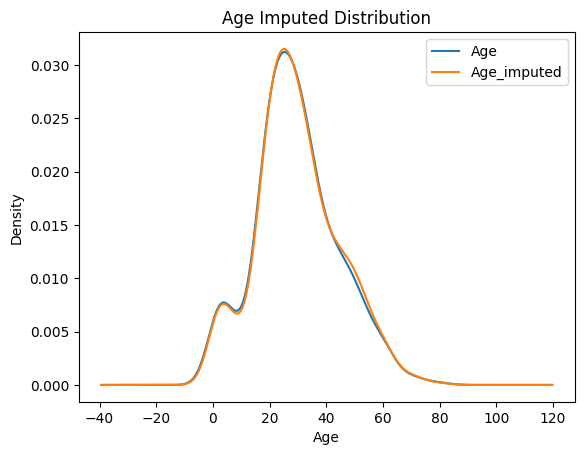

In [9]:
x_train['Age'].plot(kind='kde', title='Age Distribution')
x_train['Age_imputed'].plot(kind='kde', title='Age Imputed Distribution')
plt.legend()
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

<Axes: >

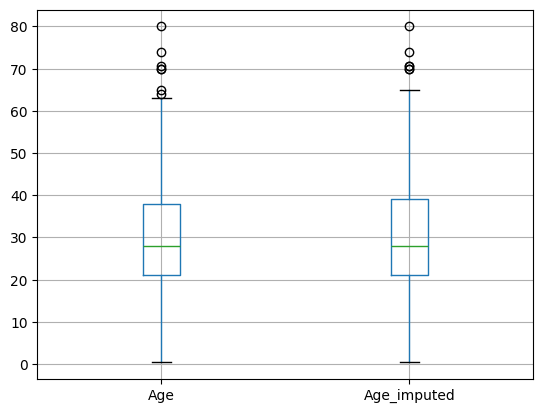

In [10]:
# To check impact on outliers.
x_train[['Age', 'Age_imputed']].boxplot()

In [11]:
#  In production, we might get missing values in 'Age column', to avoid giving different result for same set of inputs we can use observation value to set random state for sampling. This way, we will get same imputed value for same observation every time.
# observation = x_train.iloc[0]
# sampled_value = x_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))

II. Categorical data (with same steps).

In [12]:
df2 = pd.read_csv('Datasets/housing.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])
df2.sample(5)

,FireplaceQu,GarageQual,SalePrice
697,NaN,TA,123500
532,Po,TA,107500
429,TA,TA,175000
1295,NaN,TA,138500
402,NaN,TA,108000


In [13]:
df2.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [14]:
x2 = df2
y2 = df2['SalePrice']

In [15]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(x2, y2, test_size=0.2, random_state=42)
x_train2

,FireplaceQu,GarageQual,SalePrice
254,NaN,TA,145000
1066,TA,TA,178000
638,NaN,NaN,85000
799,TA,TA,175000
380,Gd,TA,127000
...,...,...,...
1095,Gd,TA,176432
1130,TA,TA,135000
1294,NaN,TA,115000
860,Gd,TA,189950


In [16]:
x_train2['GarageQual_imputed'] = x_train2['GarageQual']
x_test2['GarageQual_imputed'] = x_test2['GarageQual']

x_train2['FireplaceQu_imputed'] = x_train2['FireplaceQu']
x_test2['FireplaceQu_imputed'] = x_test2['FireplaceQu']

x_train2.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
807,TA,TA,223500,TA,TA
831,NaN,TA,151000,TA,NaN
246,NaN,Po,137000,Po,NaN
1363,Gd,TA,156932,TA,Gd
1020,NaN,TA,176000,TA,NaN


In [17]:
x_train2.loc[x_train2['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = x_train2['GarageQual'].dropna().sample(n=x_train2['GarageQual_imputed'].isnull().sum(), random_state=42).values

x_test2.loc[x_test2['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = x_test2['GarageQual'].dropna().sample(n=x_test2['GarageQual_imputed'].isnull().sum(), random_state=42).values


x_train2.loc[x_train2['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = x_train2['FireplaceQu'].dropna().sample(n=x_train2['FireplaceQu_imputed'].isnull().sum(), random_state=42).values

x_test2.loc[x_test2['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = x_test2['FireplaceQu'].dropna().sample(n=x_test2['FireplaceQu_imputed'].isnull().sum(), random_state=42).values

In [18]:
temp = pd.concat([x_train2['GarageQual'], x_train2['GarageQual_imputed']], axis=1)
temp.columns = ['GarageQual', 'GarageQual_imputed']
temp.sample(5)

,GarageQual,GarageQual_imputed
485,TA,TA
41,TA,TA
154,Fa,Fa
419,TA,TA
592,TA,TA


In [19]:
temp = pd.concat([x_train2['FireplaceQu'], x_train2['FireplaceQu_imputed']], axis=1)
temp.columns = ['FireplaceQu', 'FireplaceQu_imputed']
temp.sample(5)

,FireplaceQu,FireplaceQu_imputed
1274,Gd,Gd
658,Gd,Gd
1254,Gd,Gd
500,NaN,Gd
639,Gd,Gd


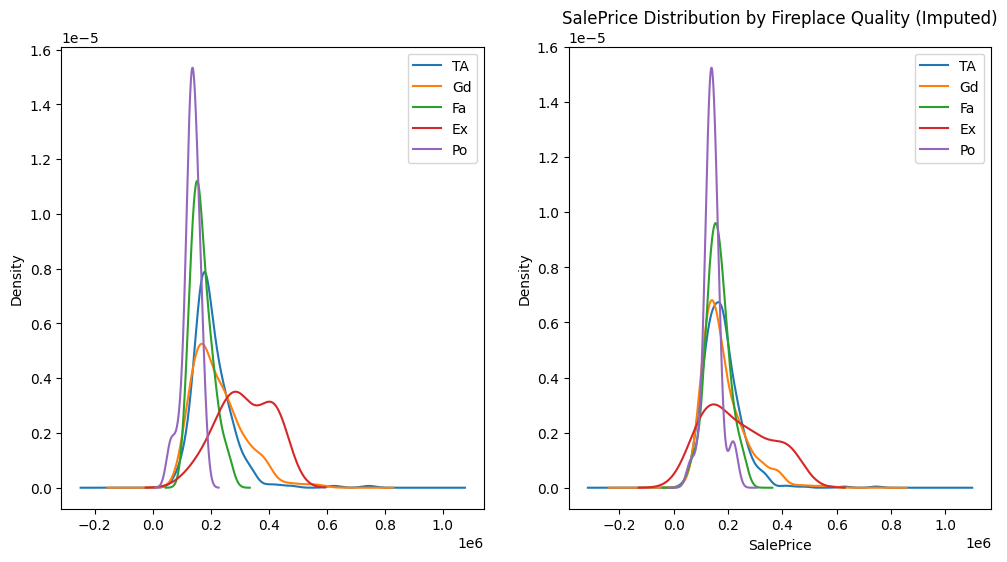

In [20]:
fig, (ax1,ax2)=plt.subplots(1,2, figsize=(12,6))

for category in x_train2['FireplaceQu'].dropna().unique():
    x_train2[x_train2['FireplaceQu'] == category]['SalePrice'].plot(kind='kde', label=category, ax = ax1)
plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.title('SalePrice Distribution by Fireplace Quality')

for category in x_train2['FireplaceQu_imputed'].dropna().unique():
    x_train2[x_train2['FireplaceQu_imputed'] == category]['SalePrice'].plot(kind='kde', label=category, ax = ax2)
plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.title('SalePrice Distribution by Fireplace Quality (Imputed)')

ax1.legend()
ax2.legend()
plt.show()

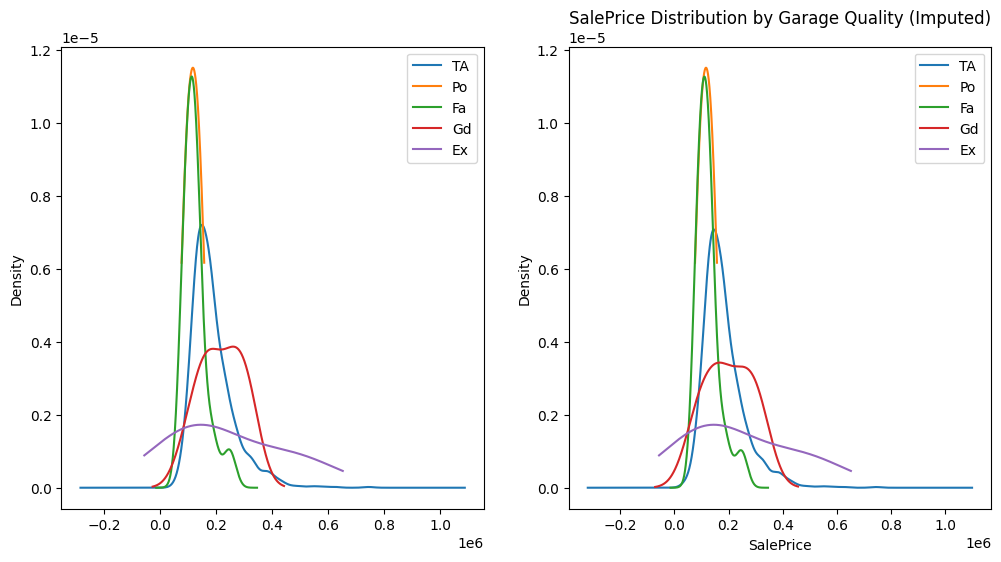

In [21]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,6))

for categories in x_train2['GarageQual'].dropna().unique():
    x_train2[x_train2['GarageQual'] == categories]['SalePrice'].plot(kind='kde', label=categories, ax = ax1)
plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.title('SalePrice Distribution by Garage Quality')

for categories in x_train2['GarageQual_imputed'].dropna().unique():
    x_train2[x_train2['GarageQual_imputed'] == categories]['SalePrice'].plot(kind='kde', label=categories, ax = ax2)
plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.title('SalePrice Distribution by Garage Quality (Imputed)')

ax1.legend()
ax2.legend()
plt.show()